<a href="https://colab.research.google.com/github/LucasMarquesLeme/Analise-de-Fabricantes/blob/main/CaseITAU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carrega todas as bibliotecas que vão ser usadas: pandas e numpy para manipular dados, matplotlib e seaborn para gráficos, scipy para estatística. Também define as cores padrão dos gráficos (azul = saudável, vermelho = deteriorado).

In [5]:
# !pip install openpyxl -q  # descomente se necessário

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo global dos gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})
CORES = ['#2196F3', '#F44336']   # azul = saudável, vermelho = deteriorado
PALETTE = {'Saudável': '#2196F3', 'Deteriorado': '#F44336'}

print("✅ Imports OK")

✅ Imports OK


Lê o Excel e mostra um diagnóstico inicial: quantas linhas/colunas tem, quantos clientes estão em deterioração (375 de 1500 = 25%), e quais colunas têm valores ausentes.

In [7]:
caminho_do_arquivo = '/carteira_credito_pj_1.xlsx'
df = pd.read_excel(caminho_do_arquivo)

print(f"Shape: {df.shape}")
print(f"\nDistribuição da variável-alvo:")
vc = df['cliente_em_deterioracao'].value_counts()
print(f"  Saudável (0):     {vc[0]:>5}  ({vc[0]/len(df):.1%})")
print(f"  Deteriorado (1):  {vc[1]:>5}  ({vc[1]/len(df):.1%})")

print(f"\nValores ausentes:")
na = df.isnull().sum()
na = na[na > 0]
for col, n in na.items():
    print(f"  {col:<35} {n:>4}  ({n/len(df):.1%})")

df.head()

Shape: (1500, 27)

Distribuição da variável-alvo:
  Saudável (0):      1125  (75.0%)
  Deteriorado (1):    375  (25.0%)

Valores ausentes:
  faturamento_mensal_r$                 45  (3.0%)
  cobertura_garantia_pct                90  (6.0%)
  pior_atraso_12m_dias                  60  (4.0%)
  saldo_custodia_r$                     75  (5.0%)


,id_cliente,setor_atividade,porte_empresa,estado,tempo_empresa_anos,faturamento_mensal_r$,divida_total_r$,garantias_oferecidas_r$,cobertura_garantia_pct,limite_credito_r$,...,saldo_medio_cc_r$,movimentacao_mensal_cc_r$,usa_capital_de_giro,saldo_capital_de_giro_r$,usa_antecipacao_recebiveis,volume_antecipado_r$,tem_custodia,saldo_custodia_r$,qtd_produtos_ativos,cliente_em_deterioracao
0,PJ00001,IndÃºstria Manufatureira,ME,SP,1,140000.0,73200.0,46200.0,0.63,214800.0,...,33800.0,98300.0,0,0.0,0,0.0,0,0.0,1,0
1,PJ00002,Tecnologia,ME,GO,1,265000.0,577400.0,423600.0,0.73,577200.0,...,153900.0,368500.0,0,0.0,1,124500.0,0,0.0,2,0
2,PJ00003,AlimentaÃ§Ã£o e Bebidas,MEI,MG,1,73900.0,163400.0,270100.0,1.65,144700.0,...,45200.0,71500.0,0,0.0,1,26200.0,0,0.0,2,0
3,PJ00004,Transporte e LogÃ­stica,ME,BA,1,397000.0,710900.0,1121900.0,1.58,491800.0,...,94800.0,373500.0,0,0.0,0,0.0,0,0.0,1,1
4,PJ00005,ComÃ©rcio Varejista,ME,PR,4,254000.0,178600.0,0.0,0.00,458900.0,...,82000.0,283300.0,1,130600.0,0,0.0,0,0.0,2,0


Preenche os valores ausentes com a mediana de cada coluna. Cria duas variáveis novas que podem ser úteis: divida_sobre_faturamento (quanto da dívida representa em relação ao que a empresa fatura) e saldo_cc_sobre_faturamento (se o saldo em conta é proporcional ao faturamento — proxy de saúde de caixa).

In [8]:
df_clean = df.copy()

# Imputação simples (mediana para numéricas com missing)
for col in ['faturamento_mensal_r$', 'cobertura_garantia_pct',
            'pior_atraso_12m_dias', 'saldo_custodia_r$']:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Label legível para gráficos
df_clean['status'] = df_clean['cliente_em_deterioracao'].map({0: 'Saudável', 1: 'Deteriorado'})

# Features derivadas úteis
df_clean['divida_sobre_faturamento'] = (
    df_clean['divida_total_r$'] / df_clean['faturamento_mensal_r$'].replace(0, np.nan)
)
df_clean['saldo_cc_sobre_faturamento'] = (
    df_clean['saldo_medio_cc_r$'] / df_clean['faturamento_mensal_r$'].replace(0, np.nan)
)
df_clean['tem_atraso_atual'] = (df_clean['dias_atraso_atual'] > 0).astype(int)

print("✅ Limpeza e engenharia de features concluídas")
print(f"Shape após limpeza: {df_clean.shape}")

✅ Limpeza e engenharia de features concluídas
Shape após limpeza: (1500, 31)


Pizza e barras mostrando a proporção 75%/25% da carteira. Importante porque o dataset é desbalanceado — isso vai impactar a modelagem.

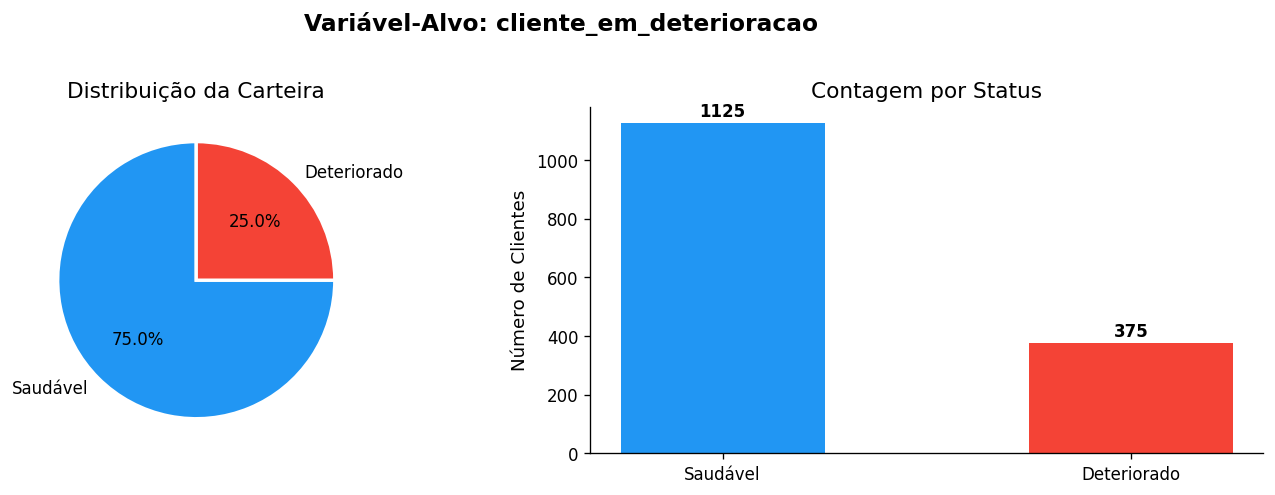

💡 Carteira desbalanceada (~25% deteriorados) — considerar isso na modelagem.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pizza
sizes = [vc[0], vc[1]]
axes[0].pie(sizes, labels=['Saudável', 'Deteriorado'], colors=CORES,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribuição da Carteira')

# Barras absolutas
bars = axes[1].bar(['Saudável', 'Deteriorado'], sizes, color=CORES, width=0.5)
for bar, val in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val}', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Número de Clientes')
axes[1].set_title('Contagem por Status')

plt.suptitle('Variável-Alvo: cliente_em_deterioracao', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_target.png', bbox_inches='tight')
plt.show()
print("💡 Carteira desbalanceada (~25% deteriorados) — considerar isso na modelagem.")

Três gráficos lado a lado mostrando o percentual de deterioração por porte (MEI tem 38%), por setor (Construção Civil lidera com 37%) e por estado (SC, MG, MT acima da média). Barras em vermelho = acima da média da carteira.

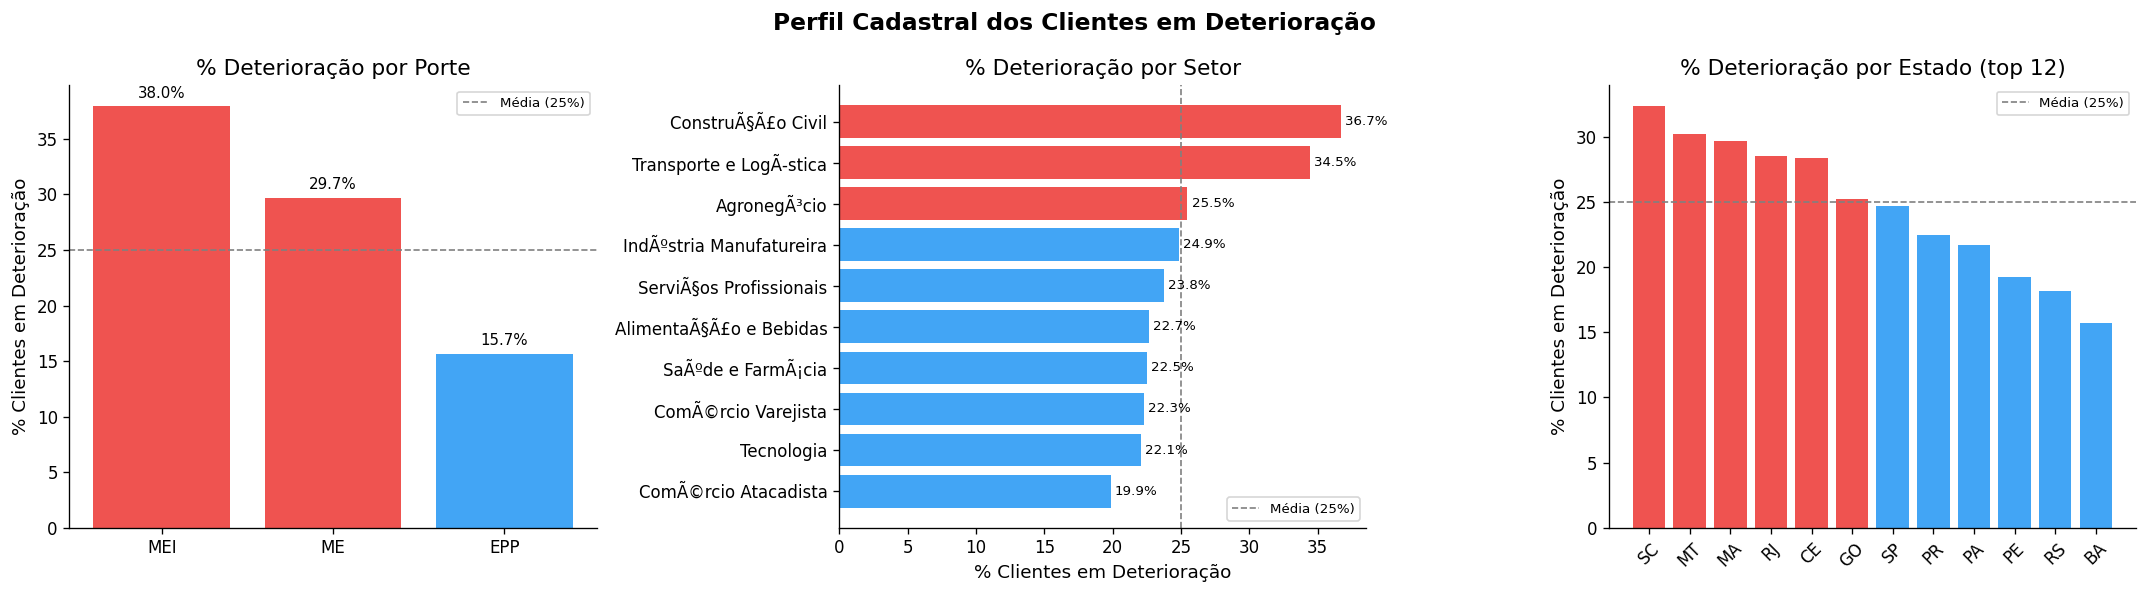

💡 MEI e ME concentram maior risco. Construção Civil e Transporte lideram por setor.
💡 SC, MG e MT com deterioração acima da média.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Porte
order_porte = ['MEI', 'ME', 'EPP', 'Médio']
det_porte = df_clean.groupby('porte_empresa')['cliente_em_deterioracao'].mean().reindex(order_porte) * 100
bars = axes[0].bar(det_porte.index, det_porte.values,
                   color=['#EF5350' if v > 25 else '#42A5F5' for v in det_porte.values])
for bar, val in zip(bars, det_porte.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].axhline(25, color='gray', linestyle='--', linewidth=1, label='Média (25%)')
axes[0].set_title('% Deterioração por Porte')
axes[0].set_ylabel('% Clientes em Deterioração')
axes[0].legend(fontsize=8)

# Setor
det_setor = df_clean.groupby('setor_atividade')['cliente_em_deterioracao'].mean().sort_values(ascending=True) * 100
cores_setor = ['#EF5350' if v > 25 else '#42A5F5' for v in det_setor.values]
axes[1].barh(det_setor.index, det_setor.values, color=cores_setor)
axes[1].axvline(25, color='gray', linestyle='--', linewidth=1, label='Média (25%)')
for i, val in enumerate(det_setor.values):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8)
axes[1].set_title('% Deterioração por Setor')
axes[1].set_xlabel('% Clientes em Deterioração')
axes[1].legend(fontsize=8)

# Estados (top 12 por volume)
top_estados = df_clean['estado'].value_counts().head(12).index
det_estado = (df_clean[df_clean['estado'].isin(top_estados)]
              .groupby('estado')['cliente_em_deterioracao'].mean()
              .sort_values(ascending=False) * 100)
cores_estado = ['#EF5350' if v > 25 else '#42A5F5' for v in det_estado.values]
axes[2].bar(det_estado.index, det_estado.values, color=cores_estado)
axes[2].axhline(25, color='gray', linestyle='--', linewidth=1, label='Média (25%)')
axes[2].set_title('% Deterioração por Estado (top 12)')
axes[2].set_ylabel('% Clientes em Deterioração')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(fontsize=8)

plt.suptitle('Perfil Cadastral dos Clientes em Deterioração', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_cadastral.png', bbox_inches='tight')
plt.show()

print("💡 MEI e ME concentram maior risco. Construção Civil e Transporte lideram por setor.")
print("💡 SC, MG e MT com deterioração acima da média.")

Histogramas comparando saudáveis vs deteriorados em 4 variáveis: utilização do limite, dias de atraso atual, meses com atraso nos últimos 12 meses e pior atraso registrado. Dá pra ver visualmente onde as distribuições se separam.

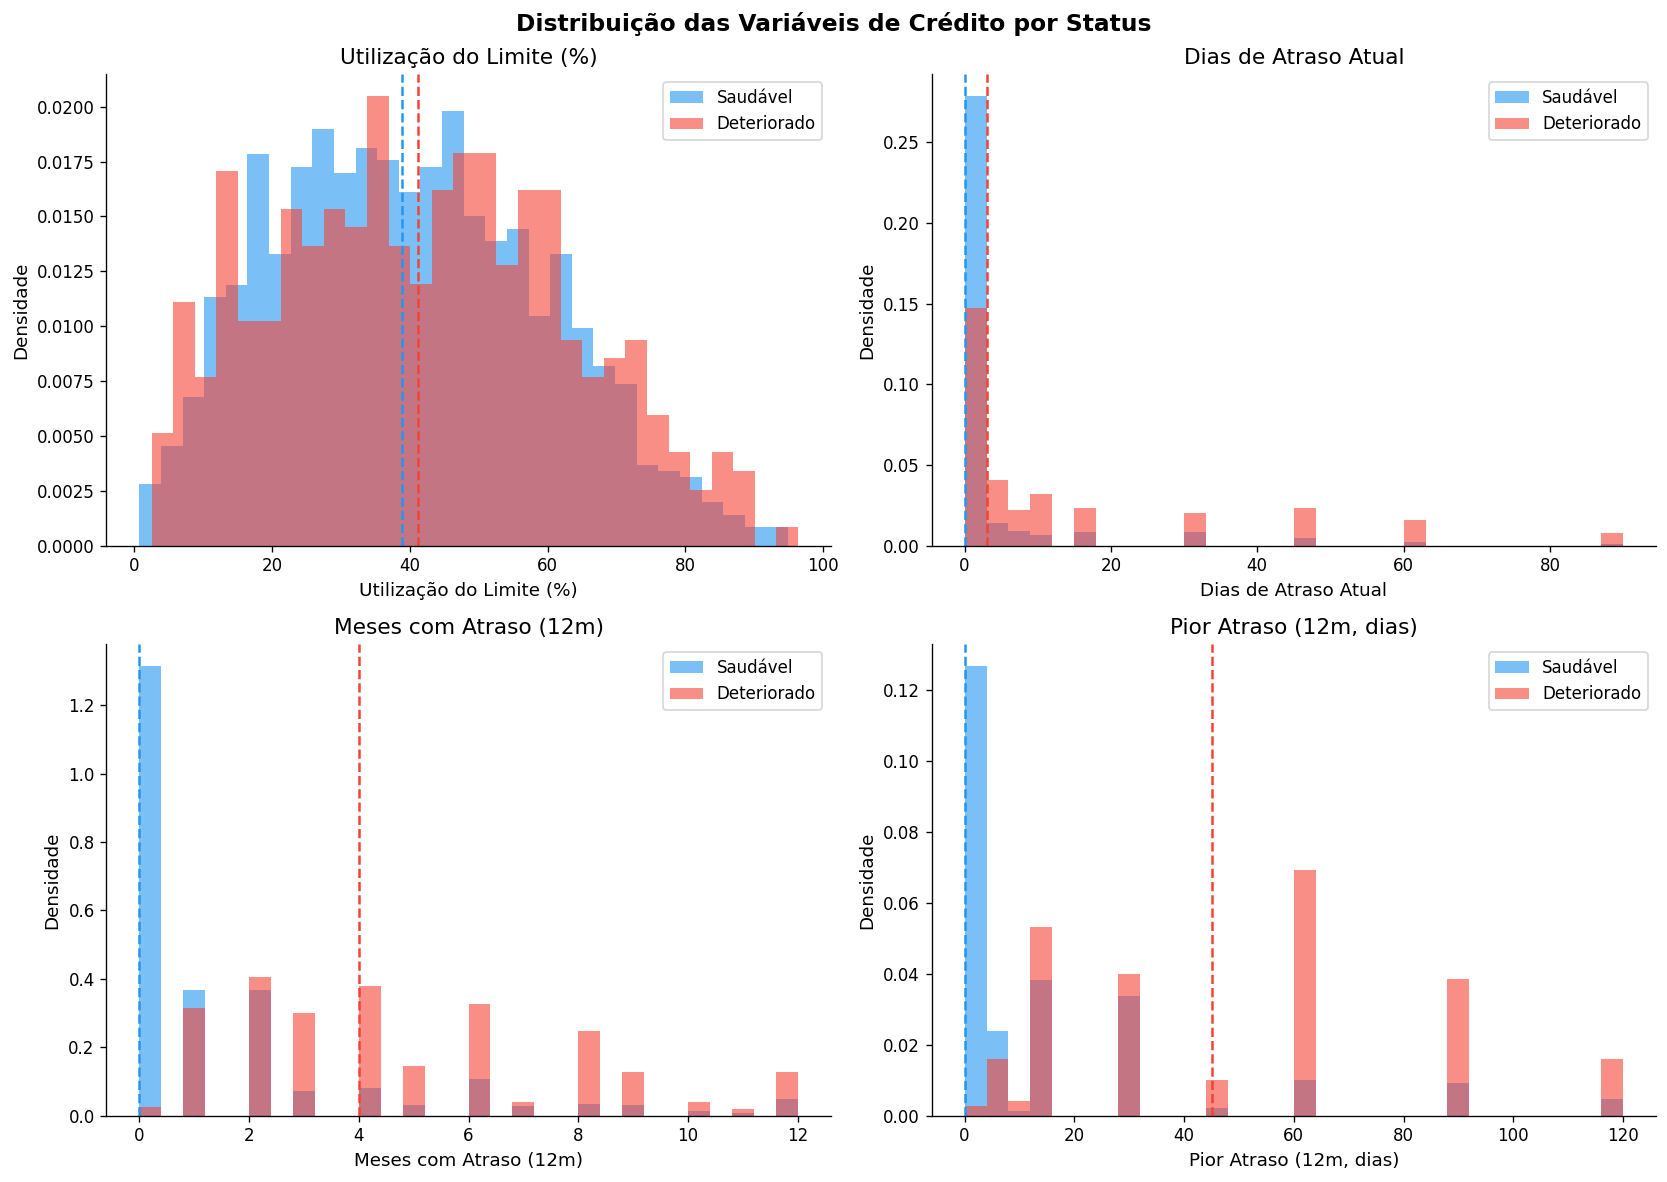

In [11]:
cols_credito = [
    ('utilizacao_limite_pct', 'Utilização do Limite (%)'),
    ('dias_atraso_atual', 'Dias de Atraso Atual'),
    ('meses_com_atraso_12m', 'Meses com Atraso (12m)'),
    ('pior_atraso_12m_dias', 'Pior Atraso (12m, dias)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, label) in zip(axes.flatten(), cols_credito):
    for status, cor in zip(['Saudável', 'Deteriorado'], CORES):
        dados = df_clean[df_clean['status'] == status][col].dropna()
        ax.hist(dados, bins=30, alpha=0.6, color=cor, label=status, density=True)
        ax.axvline(dados.median(), color=cor, linestyle='--', linewidth=1.5)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Densidade')
    ax.legend()

plt.suptitle('Distribuição das Variáveis de Crédito por Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_credito_dist.png', bbox_inches='tight')
plt.show()

Barras agrupadas mostrando a média de cada variável de crédito nos dois grupos. Fica fácil ver, por exemplo, que deteriorados têm em média 4,7 meses com atraso contra 1,6 dos saudáveis.

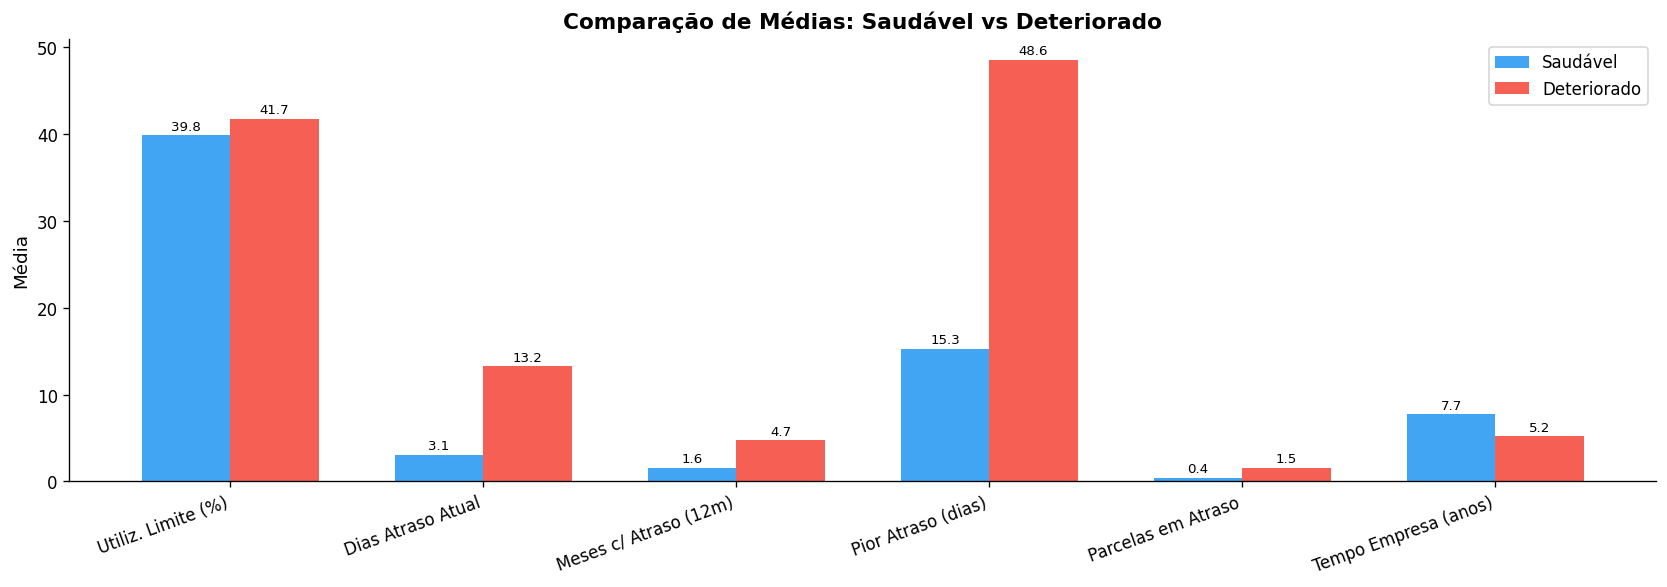

In [12]:
metricas = {
    'Utiliz. Limite (%)': 'utilizacao_limite_pct',
    'Dias Atraso Atual': 'dias_atraso_atual',
    'Meses c/ Atraso (12m)': 'meses_com_atraso_12m',
    'Pior Atraso (dias)': 'pior_atraso_12m_dias',
    'Parcelas em Atraso': 'parcelas_em_atraso',
    'Tempo Empresa (anos)': 'tempo_empresa_anos',
}

medias = {label: [df_clean[df_clean['status']=='Saudável'][col].mean(),
                   df_clean[df_clean['status']=='Deteriorado'][col].mean()]
          for label, col in metricas.items()}

x = np.arange(len(medias))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))

bars1 = ax.bar(x - width/2, [v[0] for v in medias.values()], width,
               label='Saudável', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, [v[1] for v in medias.values()], width,
               label='Deteriorado', color='#F44336', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(medias.keys(), rotation=20, ha='right')
ax.set_ylabel('Média')
ax.set_title('Comparação de Médias: Saudável vs Deteriorado', fontsize=13, fontweight='bold')
ax.legend()

# Rótulos nas barras
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig4_comparacao_medias.png', bbox_inches='tight')
plt.show()

Compara o percentual de uso de cada produto/evento nos dois grupos: renegociação, capital de giro, antecipação de recebíveis e custódia. O destaque é a renegociação: 61% dos deteriorados renegociaram vs 15% dos saudáveis.

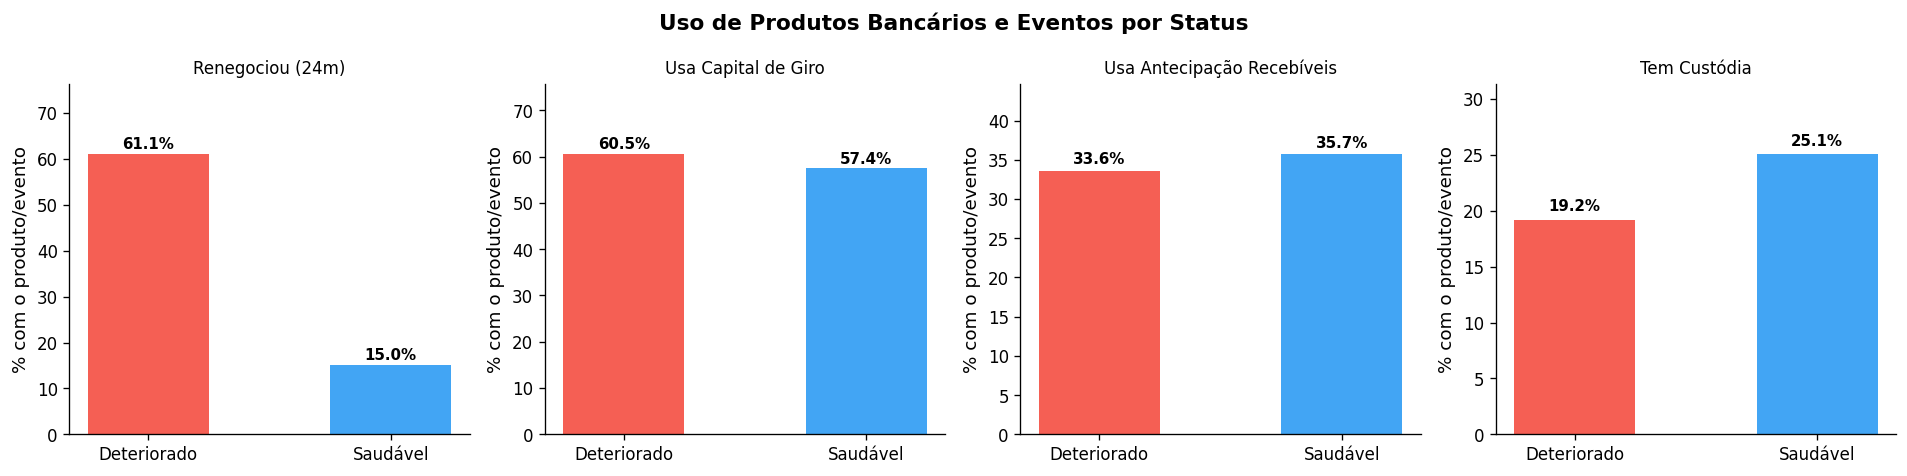

💡 Renegociação é o maior diferenciador binário: 61% dos deteriorados renegociaram vs 15% dos saudáveis.
💡 Custódia: saudáveis têm mais (25% vs 19%) — proxy de saúde financeira.


In [13]:
binarias = {
    'Renegociou (24m)': 'renegociou_24m',
    'Usa Capital de Giro': 'usa_capital_de_giro',
    'Usa Antecipação Recebíveis': 'usa_antecipacao_recebiveis',
    'Tem Custódia': 'tem_custodia',
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (label, col) in zip(axes, binarias.items()):
    vals = df_clean.groupby('status')[col].mean() * 100
    bars = ax.bar(vals.index, vals.values,
                  color=[PALETTE[s] for s in vals.index], width=0.5, alpha=0.85)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('% com o produto/evento')
    ax.set_ylim(0, max(vals.values) * 1.25)

plt.suptitle('Uso de Produtos Bancários e Eventos por Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_produtos.png', bbox_inches='tight')
plt.show()

print("💡 Renegociação é o maior diferenciador binário: 61% dos deteriorados renegociaram vs 15% dos saudáveis.")
print("💡 Custódia: saudáveis têm mais (25% vs 19%) — proxy de saúde financeira.")

Barras horizontais mostrando o quanto cada variável numérica está correlacionada com deterioração. As 4 mais fortes são todas de histórico de atraso. Variáveis financeiras (faturamento, saldo) têm correlação negativa — empresas maiores deterioram menos.


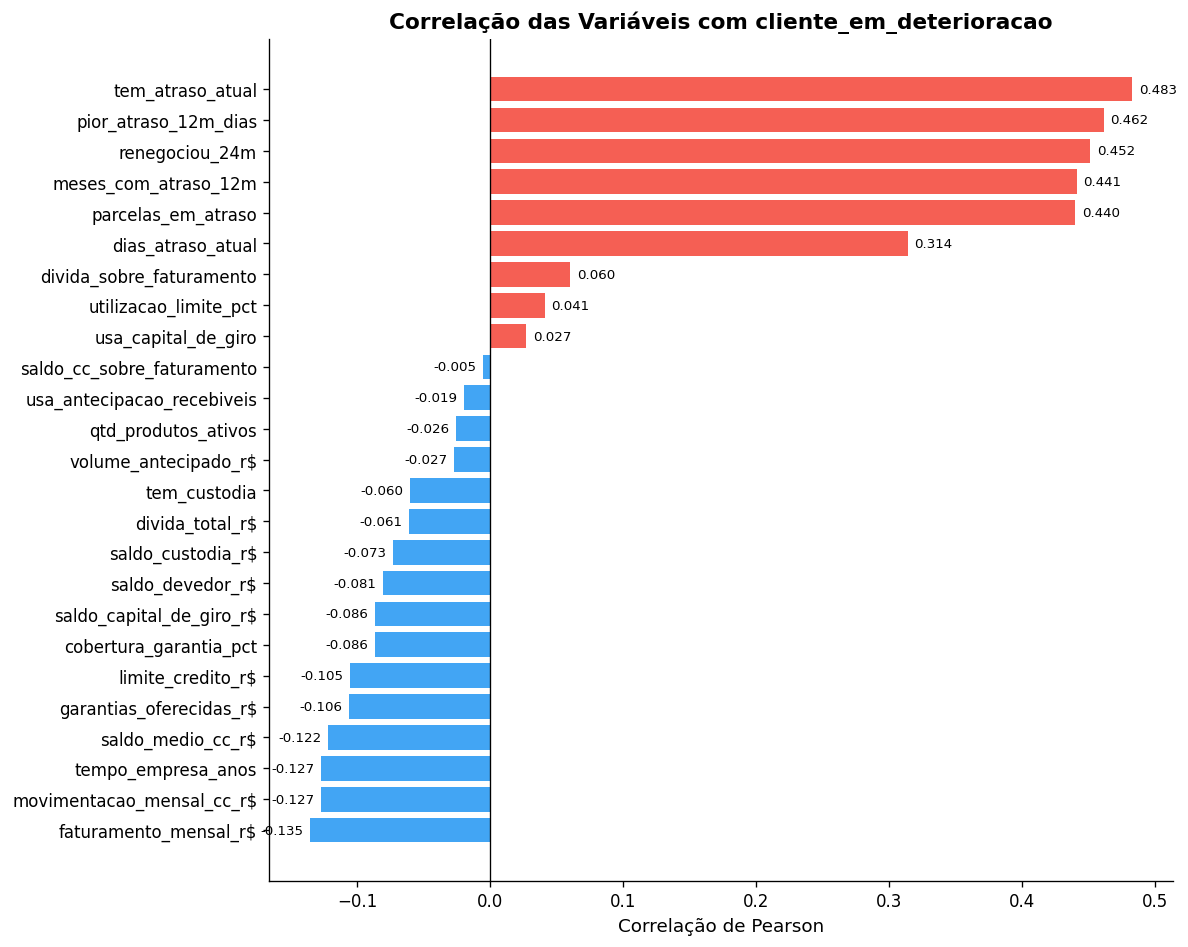

In [14]:
num_cols = df_clean.select_dtypes(include=np.number).columns
num_cols = [c for c in num_cols if c != 'cliente_em_deterioracao']
corr = df_clean[num_cols].corrwith(df_clean['cliente_em_deterioracao']).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
cores_corr = ['#F44336' if v > 0 else '#2196F3' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=cores_corr, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_title('Correlação das Variáveis com cliente_em_deterioracao', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlação de Pearson')
plt.tight_layout()
plt.savefig('fig6_correlacao.png', bbox_inches='tight')
plt.show()

 Heatmap de correlação geral

Mapa de calor mostrando a correlação entre todas as variáveis selecionadas entre si. Ajuda a identificar variáveis redundantes e entender a estrutura dos dados antes de modelar.

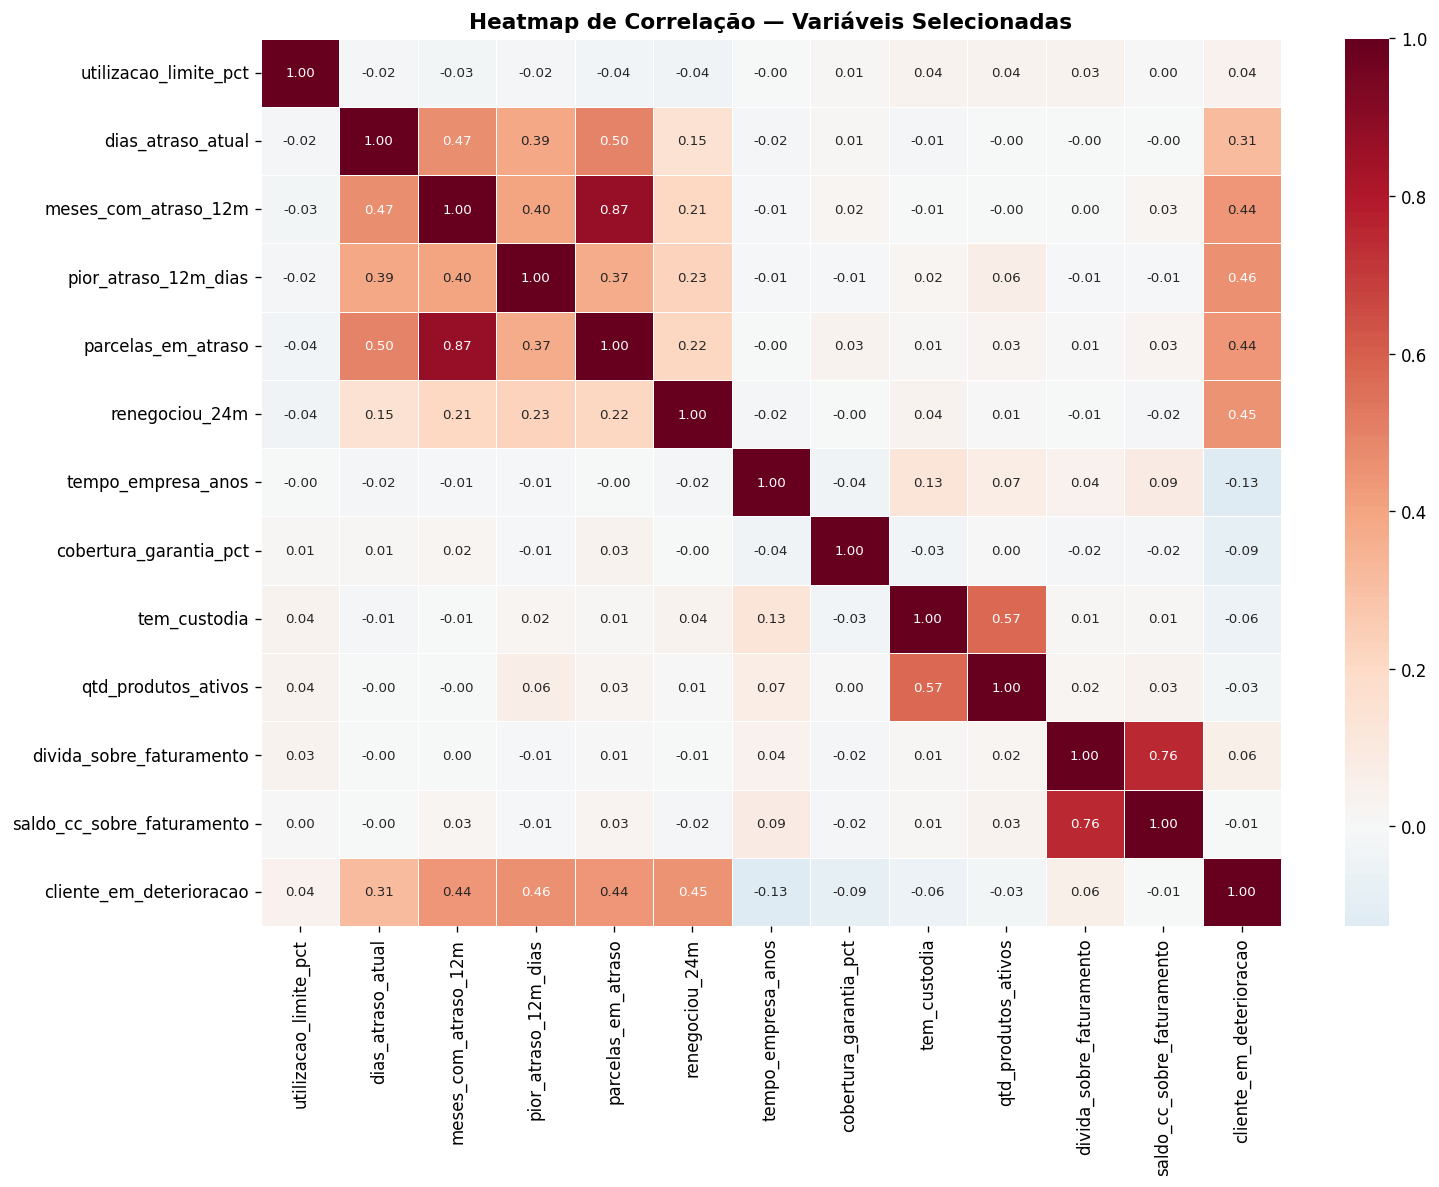

In [15]:
cols_heatmap = [
    'utilizacao_limite_pct', 'dias_atraso_atual', 'meses_com_atraso_12m',
    'pior_atraso_12m_dias', 'parcelas_em_atraso', 'renegociou_24m',
    'tempo_empresa_anos', 'cobertura_garantia_pct', 'tem_custodia',
    'qtd_produtos_ativos', 'divida_sobre_faturamento', 'saldo_cc_sobre_faturamento',
    'cliente_em_deterioracao'
]

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(df_clean[cols_heatmap].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Heatmap de Correlação — Variáveis Selecionadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_heatmap.png', bbox_inches='tight')
plt.show()

Preparação para modelagem

Seleciona as features que vão entrar no modelo, separa 80% dos dados para treino e 20% para teste (estratificado, ou seja, mantendo a proporção 75/25 em ambas as partes), e imputa NaN restantes.



In [18]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

# Features selecionadas
FEATURES = [
    'utilizacao_limite_pct', 'dias_atraso_atual', 'meses_com_atraso_12m',
    'pior_atraso_12m_dias', 'parcelas_em_atraso', 'renegociou_24m',
    'tempo_empresa_anos', 'cobertura_garantia_pct', 'tem_custodia',
    'qtd_produtos_ativos', 'faturamento_mensal_r$', 'divida_total_r$',
    'garantias_oferecidas_r$', 'limite_credito_r$', 'saldo_devedor_r$',
    'saldo_medio_cc_r$', 'movimentacao_mensal_cc_r$',
    'usa_capital_de_giro', 'usa_antecipacao_recebiveis',
    'volume_antecipado_r$', 'saldo_custodia_r$',
    'divida_sobre_faturamento', 'saldo_cc_sobre_faturamento',
]

X = df_clean[FEATURES].copy()
y = df_clean['cliente_em_deterioracao']

# Imputar eventuais NaN restantes (features derivadas podem ter)
X.fillna(X.median(), inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Prevalência treino: {y_train.mean():.1%} | Prevalência teste: {y_test.mean():.1%}")

Train: (1200, 23) | Test: (300, 23)
Prevalência treino: 25.0% | Prevalência teste: 25.0%


 Treino de 3 modelos

Treina Regressão Logística, Random Forest e Gradient Boosting. Usa validação cruzada com 5 folds para estimar o AUC de cada modelo de forma robusta, depois avalia no conjunto de teste. Todos usam class_weight='balanced' para compensar o desbalanceamento.

In [19]:
modelos = {
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}

for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc')
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc_test = roc_auc_score(y_test, y_prob)
    resultados[nome] = {
        'modelo': modelo,
        'cv_auc_mean': scores.mean(),
        'cv_auc_std': scores.std(),
        'auc_test': auc_test,
        'y_pred': y_pred,
        'y_prob': y_prob,
    }
    print(f"\n{'='*50}")
    print(f"🔹 {nome}")
    print(f"   CV AUC: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"   Test AUC: {auc_test:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Saudável', 'Deteriorado']))


🔹 Regressão Logística
   CV AUC: 0.9124 ± 0.0246
   Test AUC: 0.9077
              precision    recall  f1-score   support

    Saudável       0.94      0.82      0.88       225
 Deteriorado       0.61      0.85      0.71        75

    accuracy                           0.83       300
   macro avg       0.78      0.84      0.79       300
weighted avg       0.86      0.83      0.83       300


🔹 Random Forest
   CV AUC: 0.9355 ± 0.0118
   Test AUC: 0.9467
              precision    recall  f1-score   support

    Saudável       0.94      0.91      0.93       225
 Deteriorado       0.76      0.83      0.79        75

    accuracy                           0.89       300
   macro avg       0.85      0.87      0.86       300
weighted avg       0.89      0.89      0.89       300


🔹 Gradient Boosting
   CV AUC: 0.9520 ± 0.0144
   Test AUC: 0.9617
              precision    recall  f1-score   support

    Saudável       0.91      0.96      0.94       225
 Deteriorado       0.86      0.72  

Plota as curvas ROC dos 3 modelos no mesmo gráfico para comparar visualmente. Quanto mais a curva se aproxima do canto superior esquerdo, melhor o modelo.

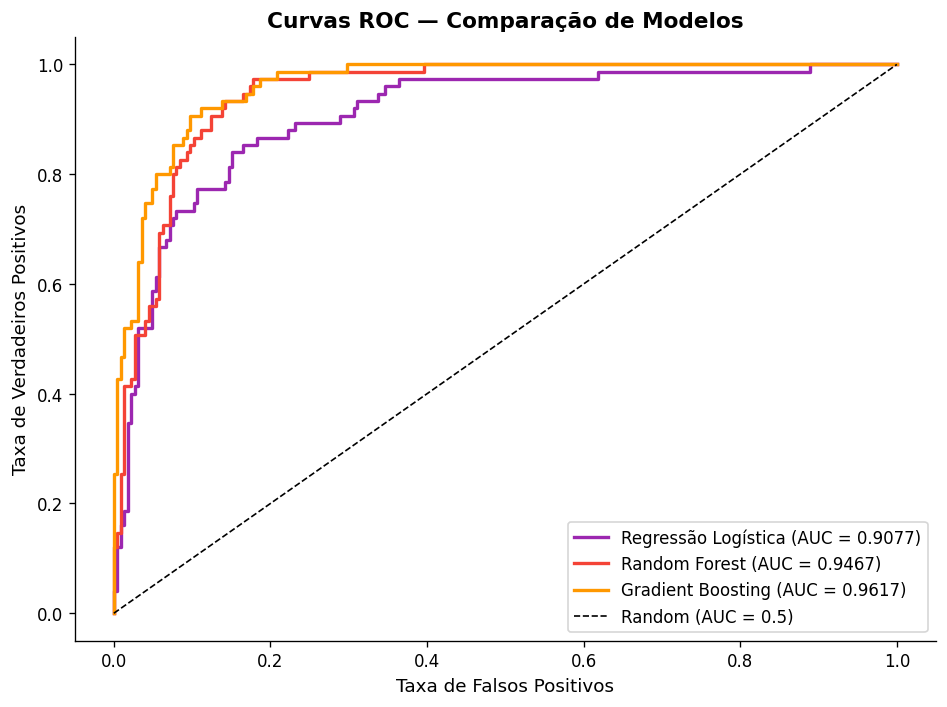

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
cores_roc = ['#9C27B0', '#F44336', '#FF9800']

for (nome, res), cor in zip(resultados.items(), cores_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=cor, lw=2,
            label=f"{nome} (AUC = {res['auc_test']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curvas ROC — Comparação de Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig8_roc.png', bbox_inches='tight')
plt.show()

Mostra para o melhor modelo quantos acertos e erros ele teve: verdadeiros positivos (detectou deterioração corretamente), falsos negativos (não detectou quando deveria), etc.

✅ Melhor modelo: Gradient Boosting (AUC = 0.9617)


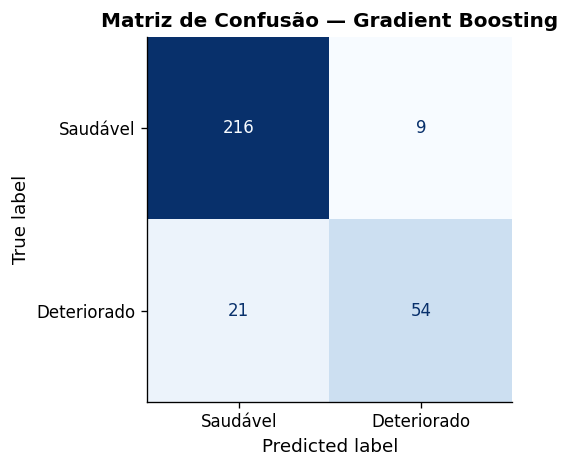

In [21]:
melhor_nome = max(resultados, key=lambda k: resultados[k]['auc_test'])
melhor = resultados[melhor_nome]
print(f"✅ Melhor modelo: {melhor_nome} (AUC = {melhor['auc_test']:.4f})")

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, melhor['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'Deteriorado'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusão — {melhor_nome}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_confusion.png', bbox_inches='tight')
plt.show()

Mostra quais variáveis o Random Forest considerou mais importantes para tomar a decisão. As 5 primeiras ficam em vermelho para destacar. Importante para justificar o modelo ao gestor.

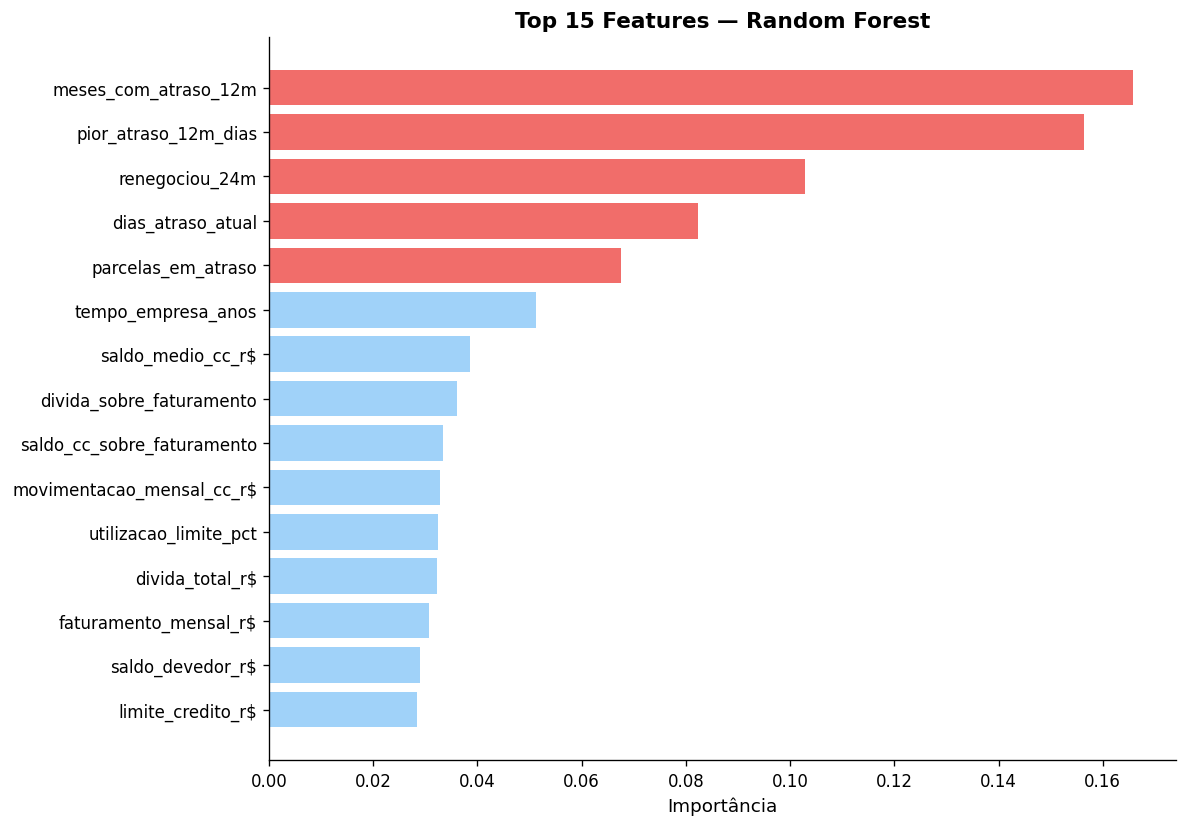


Top 10 features mais importantes:
  meses_com_atraso_12m                     0.1658
  pior_atraso_12m_dias                     0.1564
  renegociou_24m                           0.1029
  dias_atraso_atual                        0.0822
  parcelas_em_atraso                       0.0676
  tempo_empresa_anos                       0.0513
  saldo_medio_cc_r$                        0.0386
  divida_sobre_faturamento                 0.0360
  saldo_cc_sobre_faturamento               0.0333
  movimentacao_mensal_cc_r$                0.0329


In [22]:
rf = resultados['Random Forest']['modelo']
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_features = importances.head(15)
cores_fi = ['#EF5350' if i < 5 else '#90CAF9' for i in range(len(top_features))]
ax.barh(top_features.index[::-1], top_features.values[::-1], color=cores_fi[::-1], alpha=0.85)
ax.set_xlabel('Importância')
ax.set_title('Top 15 Features — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 10 features mais importantes:")
for feat, val in importances.head(10).items():
    print(f"  {feat:<40} {val:.4f}")

Score de risco para a carteira toda

Usa o melhor modelo para atribuir uma probabilidade de deterioração a cada um dos 1500 clientes. Divide em 4 faixas (Q1 a Q4) e mostra o perfil de cada faixa — quantos clientes, qual % está em deterioração, faturamento médio, etc.

📊 Segmentação da Carteira por Faixa de Risco:
     faixa_risco  n_clientes  pct_deteriorados  score_medio  faturamento_medio  utilizacao_media  meses_atraso_medio
      Baixo (Q1)         375               0.0        0.003          2222821.0              38.6                 0.2
Médio-Baixo (Q2)         375               0.0        0.010          1465745.0              42.5                 1.1
 Médio-Alto (Q3)         375               4.5        0.093          1639391.0              38.3                 3.5
       Alto (Q4)         375              95.5        0.867          1055115.0              41.9                 4.7


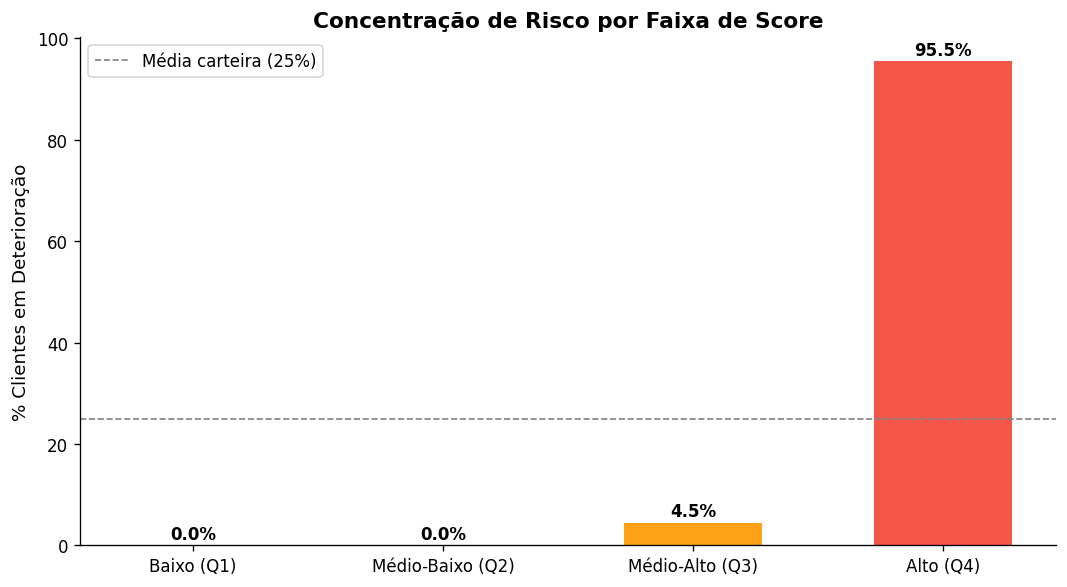

In [23]:
melhor_modelo = melhor['modelo']
df_clean['score_risco'] = melhor_modelo.predict_proba(X)[:, 1]

# Segmentar em quartis de risco
df_clean['faixa_risco'] = pd.qcut(
    df_clean['score_risco'], q=4,
    labels=['Baixo (Q1)', 'Médio-Baixo (Q2)', 'Médio-Alto (Q3)', 'Alto (Q4)']
)

tabela_risco = df_clean.groupby('faixa_risco').agg(
    n_clientes=('id_cliente', 'count'),
    pct_deteriorados=('cliente_em_deterioracao', 'mean'),
    score_medio=('score_risco', 'mean'),
    faturamento_medio=('faturamento_mensal_r$', 'mean'),
    utilizacao_media=('utilizacao_limite_pct', 'mean'),
    meses_atraso_medio=('meses_com_atraso_12m', 'mean'),
).reset_index()

tabela_risco['pct_deteriorados'] = (tabela_risco['pct_deteriorados'] * 100).round(1)
tabela_risco['score_medio'] = tabela_risco['score_medio'].round(3)
tabela_risco['faturamento_medio'] = tabela_risco['faturamento_medio'].round(0)
tabela_risco['utilizacao_media'] = tabela_risco['utilizacao_media'].round(1)
tabela_risco['meses_atraso_medio'] = tabela_risco['meses_atraso_medio'].round(1)

print("📊 Segmentação da Carteira por Faixa de Risco:")
print(tabela_risco.to_string(index=False))

# Gráfico de barras — % deteriorados por faixa
fig, ax = plt.subplots(figsize=(9, 5))
cores_faixa = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336']
bars = ax.bar(tabela_risco['faixa_risco'], tabela_risco['pct_deteriorados'],
              color=cores_faixa, width=0.55, alpha=0.9)
for bar, val in zip(bars, tabela_risco['pct_deteriorados']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.axhline(25, color='gray', linestyle='--', linewidth=1, label='Média carteira (25%)')
ax.set_ylabel('% Clientes em Deterioração')
ax.set_title('Concentração de Risco por Faixa de Score', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig11_score_faixas.png', bbox_inches='tight')
plt.show()

Salva um Excel com todos os clientes ordenados pelo score de risco, incluindo a faixa de risco e as principais variáveis. Esse arquivo é a entrega prática para a equipe comercial usar.

In [24]:
colunas_export = [
    'id_cliente', 'setor_atividade', 'porte_empresa', 'estado',
    'score_risco', 'faixa_risco', 'cliente_em_deterioracao',
    'utilizacao_limite_pct', 'meses_com_atraso_12m', 'renegociou_24m',
    'dias_atraso_atual', 'pior_atraso_12m_dias',
]

df_export = df_clean[colunas_export].sort_values('score_risco', ascending=False)
df_export.to_excel('carteira_com_scores.xlsx', index=False)
print("✅ Arquivo 'carteira_com_scores.xlsx' gerado com sucesso.")
print(f"\nTop 10 clientes de maior risco:")
print(df_export.head(10).to_string(index=False))

✅ Arquivo 'carteira_com_scores.xlsx' gerado com sucesso.

Top 10 clientes de maior risco:
id_cliente          setor_atividade porte_empresa estado  score_risco faixa_risco  cliente_em_deterioracao  utilizacao_limite_pct  meses_com_atraso_12m  renegociou_24m  dias_atraso_atual  pior_atraso_12m_dias
   PJ01311      ComÃ©rcio Varejista            ME     SP     0.996433   Alto (Q4)                        1                   20.0                     4               1                 15                  60.0
   PJ00677      ComÃ©rcio Varejista            ME     PA     0.996348   Alto (Q4)                        1                   24.3                     8               1                  1                  30.0
   PJ00856      ComÃ©rcio Varejista           MEI     SC     0.996088   Alto (Q4)                        1                   27.8                     2               1                 10                  60.0
   PJ00244 IndÃºstria Manufatureira           MEI     SP     0.995360   Al

Imprime no terminal um resumo consolidado: achados principais, performance dos modelos, perfil da faixa de alto risco e lista dos arquivos gerados. Serve como rascunho para o relatório.

In [25]:
auc_rf  = resultados['Random Forest']['auc_test']
auc_gb  = resultados['Gradient Boosting']['auc_test']
auc_lr  = resultados['Regressão Logística']['auc_test']
n_alto  = (df_clean['faixa_risco'] == 'Alto (Q4)').sum()
pct_alto = df_clean[df_clean['faixa_risco'] == 'Alto (Q4)']['cliente_em_deterioracao'].mean()

print("=" * 60)
print("   RESUMO EXECUTIVO — CASE CRÉDITO PJ")
print("=" * 60)
print(f"""
CARTEIRA ANALISADA
  • 1.500 empresas | 25% em deterioração (375 clientes)
  • Dataset desbalanceado — modelos treinados com class_weight='balanced'

PRINCIPAIS ACHADOS
  • Variáveis com maior poder preditivo:
      1. Histórico de atrasos (pior_atraso_12m, meses_com_atraso_12m)
      2. Renegociação nos últimos 24m (61% vs 15% nos saudáveis)
      3. Parcelas em atraso e dias de atraso atual
  • Perfil de risco elevado: MEI/ME, Construção Civil, Transporte
  • Custódia bancária = proxy de saúde financeira

PERFORMANCE DOS MODELOS
  • Regressão Logística  AUC = {auc_lr:.4f}
  • Random Forest        AUC = {auc_rf:.4f}
  • Gradient Boosting    AUC = {auc_gb:.4f}

SEGMENTAÇÃO POR SCORE
  • Faixa de Alto Risco (Q4): {n_alto} clientes | {pct_alto:.1%} em deterioração
  • Recomendação: acionar equipe comercial para clientes Q4 e Q3

ARQUIVOS GERADOS
  • fig1_target.png até fig11_score_faixas.png
  • carteira_com_scores.xlsx
""")

   RESUMO EXECUTIVO — CASE CRÉDITO PJ

CARTEIRA ANALISADA
  • 1.500 empresas | 25% em deterioração (375 clientes)
  • Dataset desbalanceado — modelos treinados com class_weight='balanced'
 
PRINCIPAIS ACHADOS
  • Variáveis com maior poder preditivo:
      1. Histórico de atrasos (pior_atraso_12m, meses_com_atraso_12m)
      2. Renegociação nos últimos 24m (61% vs 15% nos saudáveis)
      3. Parcelas em atraso e dias de atraso atual
  • Perfil de risco elevado: MEI/ME, Construção Civil, Transporte
  • Custódia bancária = proxy de saúde financeira
 
PERFORMANCE DOS MODELOS
  • Regressão Logística  AUC = 0.9077
  • Random Forest        AUC = 0.9467
  • Gradient Boosting    AUC = 0.9617
 
SEGMENTAÇÃO POR SCORE
  • Faixa de Alto Risco (Q4): 375 clientes | 95.5% em deterioração
  • Recomendação: acionar equipe comercial para clientes Q4 e Q3
 
ARQUIVOS GERADOS
  • fig1_target.png até fig11_score_faixas.png
  • carteira_com_scores.xlsx

